In [2]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from brise.rise import RISE
import brise.utils as utils
from brise.utils import IMAGES

In [3]:
from tqdm import tqdm


class B_RISE(nn.Module):
    def __init__(self, model, x, gpu_batch=100, device=None):
        super(B_RISE, self).__init__()
        self.model = model
        _, _, H, W = x.shape
        self.input_size = (H, W)
        self.gpu_batch = gpu_batch
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def generate_masks(self, N, s, p, mode='bilinear'):
        # check if mode is bilinear or nearest, otherwise raise an error
        assert mode in ['bilinear', 'nearest'], "Mode must be either 'bilinear' or 'nearest'"

        cell_size = np.ceil(np.array(self.input_size) / s).astype(int)
        self.up_size = (s + 1) * cell_size  # +1 so we can shift grids

        grids = np.random.rand(N, s, s) < p
        self.grids = grids.astype("float32")

        self.shifts = []
        for _ in range(N):
            x_shift = np.random.randint(0, cell_size[0])
            y_shift = np.random.randint(0, cell_size[1])
            self.shifts.append((x_shift, y_shift))

        self.N = N
        self.s = s
        self.p = p
        self.mode = mode

    def resize_mask(self, mask, up_size, mode='bilinear'):
        mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)  # (1,1,s,s)
        if mode == 'bilinear':
            mask_up = F.interpolate(mask_t, size=up_size.tolist(), mode='bilinear', align_corners=False)
        else:
            mask_up = F.interpolate(mask_t, size=up_size.tolist(), mode=mode)

        return mask_up.squeeze()
    
    def render_grid(self, grid_np, shift):
        up_mask = self.resize_mask(grid_np, self.up_size, mode=self.mode)

        x, y = shift
        cropped = up_mask[x:x + self.input_size[0], y:y + self.input_size[1]]

        return cropped.unsqueeze(0).unsqueeze(0)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

In [5]:
img_path = IMAGES / "catdog.png"
img, img_x = utils.load_image(img_path, device, preprocess)

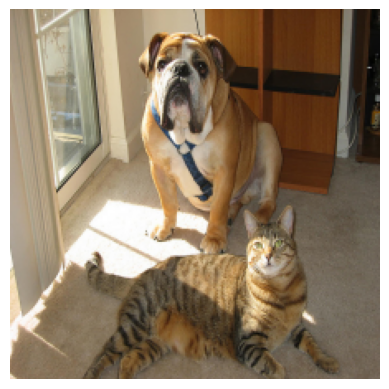

In [6]:
utils.draw_image(img)

In [7]:
b_rise = B_RISE(model, img_x)

In [8]:
b_rise.generate_masks(100, 7, 0.5)

In [9]:
K = None
x = img_x

forwardpass_estimate = b_rise.N * (1 + (K if K is not None else b_rise.s**2 * (1-b_rise.p)))
print(f"Estimated forward passes: {forwardpass_estimate}")

Estimated forward passes: 2550.0


In [10]:
with torch.no_grad():
    num_classes = b_rise.model(x).shape[1]

In [11]:
num_classes

1000

In [12]:
H, W = b_rise.input_size
saliency = torch.zeros(num_classes, H, W, device=b_rise.device)
forwardpass_counter = 0

In [13]:
saliency.shape, H, W

(torch.Size([1000, 224, 224]), 224, 224)

In [14]:
idx_N = 0
grid = b_rise.grids[idx_N]
shift = b_rise.shifts[idx_N]

In [15]:
grid, shift

(array([[0., 0., 1., 1., 0., 0., 1.],
        [0., 1., 1., 0., 0., 0., 1.],
        [0., 1., 1., 0., 1., 1., 1.],
        [0., 1., 0., 0., 0., 1., 1.],
        [0., 1., 1., 0., 0., 1., 1.],
        [0., 1., 1., 1., 0., 1., 0.],
        [1., 1., 1., 0., 1., 0., 0.]], dtype=float32),
 (9, 11))

In [16]:
base_mask = b_rise.render_grid(grid, shift).to(b_rise.device)       # (1,1,H,W)
with torch.no_grad():
    baseline = b_rise.model(x * base_mask)                    # (1,num_classes)
    forwardpass_counter += 1

In [17]:
base_mask.shape, baseline.shape

(torch.Size([1, 1, 224, 224]), torch.Size([1, 1000]))

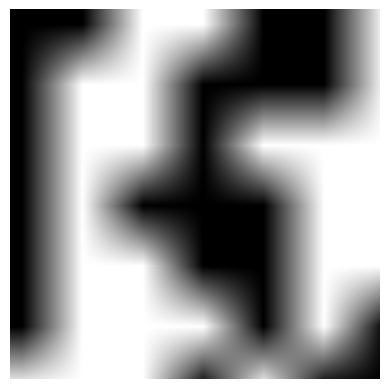

In [18]:
utils.draw_mask(base_mask)

In [19]:
zero_positions = np.argwhere(grid == 0)
M = len(zero_positions)

In [20]:
M, zero_positions

(23,
 array([[0, 0],
        [0, 1],
        [0, 4],
        [0, 5],
        [1, 0],
        [1, 3],
        [1, 4],
        [1, 5],
        [2, 0],
        [2, 3],
        [3, 0],
        [3, 2],
        [3, 3],
        [3, 4],
        [4, 0],
        [4, 3],
        [4, 4],
        [5, 0],
        [5, 4],
        [5, 6],
        [6, 3],
        [6, 5],
        [6, 6]]))

In [21]:
K = 5

In [22]:
if K is not None and M > K:
    sampled_indices = np.random.choice(M, K, replace=False)
    sampled_positions = zero_positions[sampled_indices]
    scale = M / K           # Scale factor to account for sampling fewer subsets, >1 if K < M (sampling)
else:
    sampled_positions = zero_positions
    scale = 1.0             # 1 if no sampling 

In [23]:
scale, sampled_positions, K

(4.6,
 array([[0, 0],
        [6, 6],
        [3, 3],
        [3, 2],
        [0, 4]]),
 5)

In [24]:
# calculate flipped masks for all zero positions
flipped_masks = []

for (i, j) in sampled_positions:
    flipped_grid = grid.copy()
    flipped_grid[i, j] = 1

    mask = b_rise.render_grid(flipped_grid, shift)
    flipped_masks.append(mask)

# Stack into batch
flipped_masks = torch.cat(flipped_masks, dim=0).to(b_rise.device)     # (K,1,H,W)

In [25]:
flipped_masks.shape

torch.Size([5, 1, 224, 224])

In [26]:
# Batch forward
with torch.no_grad():
    outputs = b_rise.model(x * flipped_masks)
    forwardpass_counter += flipped_masks.shape[0]

In [27]:
forwardpass_counter

6

In [28]:
outputs.shape

torch.Size([5, 1000])

In [29]:
diffs = outputs - baseline

In [30]:
baseline.shape

torch.Size([1, 1000])

In [31]:
diffs[0][0], outputs[0][0], baseline[0][0]

(tensor(-0.0345, device='cuda:0'),
 tensor(-0.3623, device='cuda:0'),
 tensor(-0.3277, device='cuda:0'))

In [32]:
diffs[1][0], outputs[1][0], baseline[0][0]

(tensor(0.0023, device='cuda:0'),
 tensor(-0.3254, device='cuda:0'),
 tensor(-0.3277, device='cuda:0'))

In [33]:
diffs.shape

torch.Size([5, 1000])

In [34]:
idx = 0
diff_vec = diffs[idx]

delta_mask = flipped_masks[idx] - base_mask.squeeze(0)          # (1,H,W)


In [35]:
base_mask.squeeze(0).shape

torch.Size([1, 224, 224])

In [36]:
flipped_masks[0].shape

torch.Size([1, 224, 224])

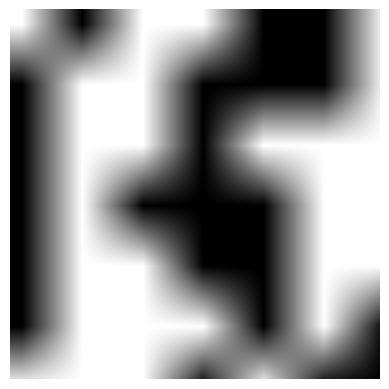

In [38]:
utils.draw_mask(flipped_masks[0])

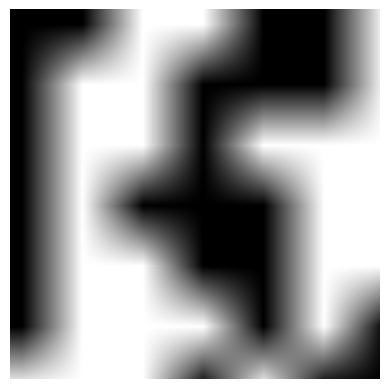

In [39]:
utils.draw_mask(base_mask.squeeze(0))

In [40]:
delta_mask.shape

torch.Size([1, 224, 224])

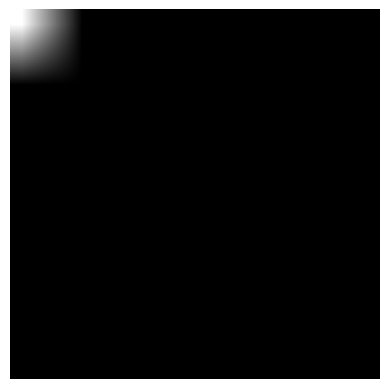

In [41]:
utils.draw_mask(delta_mask)

In [42]:
saliency += diff_vec.view(-1, 1, 1) * delta_mask * scale        # (num_classes,H,W)

In [43]:
diff_vec.view(-1, 1, 1).shape, delta_mask.shape, scale

(torch.Size([1000, 1, 1]), torch.Size([1, 224, 224]), 4.6)

In [44]:
saliency.shape

torch.Size([1000, 224, 224])